# Deletion-near-contraction fundamentals

Core SageMath routines for computing the chromatic symmetric function in the star basis via the deletion-near-contraction recurrence.

In [5]:
import numpy as np
from sage.all import *

# Deletion on e
def left_operation(F, e):
    """Delete edge ``e`` from ``F`` in place and return the resulting forest."""
    F.delete_edge(e)
    return F

# Contraction on e plus singleton
def middle_operation(F, e):
    """Apply the contraction-plus-singleton term of the DNC relation."""
    F.contract_edge(e)
    F.add_vertex()
    return F

# Contraction on e plus singleton and edge
def right_operation(F, e):
    """Apply the contraction-plus-singleton-and-edge term of the DNC relation."""
    F.contract_edge(e)
    F.add_vertex()
    F.add_edge(e)
    return F

In [6]:
# If tree has an internal edge, it returns one; otherwise, returns None
def get_internal_edge(F):
    """Return one internal edge of ``F``, or ``None`` if no such edge exists."""
    for e in F.edges(labels=False):
        if F.degree(e)[0] > 1 and F.degree(e)[1] > 1:
            return e
    return None

# Get the list of internal edges
def list_internal_edges(T):
    """Return all edges of ``T`` whose endpoints both have degree greater than one."""
    internal_edges = []
    for e in T.edges(labels=False):
        if T.degree(e)[0] > 1 and T.degree(e)[1] > 1:
            internal_edges.append(e)
    return internal_edges

# Get leading partition from the tree itself
def leading_partition(T):
    """Delete the internal edges of ``T`` in place and return the component sizes."""
    internal_edges = list_internal_edges(T)
    
    for e in internal_edges:
        T.delete_edge(e)
        
    return T.connected_components_sizes()

# Return number of internal edges from the tree
def number_internal_edges(tree):
    """Count the internal edges of ``tree``."""
    count = 0
    for e in tree.edges(labels=False):
        if (tree.degree(e)[0] > 1) and (tree.degree(e)[1] > 1):
            count = count + 1
    return count

def string_sign(x):
    """Return the printable sign associated with ``x``."""
    sign = ""
    if x>0:
        sign = sign + "+"
    else:
        sign = sign + "-"

    return sign

# Input: array p
# Output: returns the number of 1's in p
def num_singletons(p):
    """Count the parts equal to one in ``p``."""
    num = 0
    for i in p:
        if i == 1:
            num += 1
    return num

# Input: an integer partition p, the set of partitions of n
# Output: returns the index of p in Partitions(n), assuming lexicographic ordering and zero-indexing
def get_index(p, partitions):
    """Return the zero-based index of partition ``p`` in ``partitions``."""
    i = 0
    for partition in partitions:
        if partition == p:
            return int(i)
        else:
            i += 1

# Input: a CSF vector, and the number of vertices n           
# Output: returns the leading partition 
def get_leading_partition(vector, n):
    """Return the leading partition represented by a nonzero CSF coefficient vector."""
    partitions = Partitions(n).list()
    leading = 0 
    count = 0
    
    while count < len(partitions):
        if vector[count] != 0:
            leading = vector[count]
            last_index = count
        count += 1

    return partitions[last_index]

def create_tree(vertex_list, edge_list):
    """Build a Sage graph from a vertex list and an edge list."""
    G = Graph()
    for i in range(0, len(vertex_list)):
        G.add_vertex()
    for edge in edge_list:
        G.add_edge(edge)
        
    # G.plot().show()
    return G

def partitions_in_tree(csfvector, n):
    """Return the partition prefix ending at the leading partition of ``csfvector``."""
    partitions = Partitions(n).list()
    vector_partition_list = []
    l_p = get_leading_partition(csfvector, n)
    
    for i in range(0, len(partitions)):
        if partitions[i] != l_p:
            vector_partition_list.append(partitions[i])
        else:
            vector_partition_list.append(l_p)
            break
    
    return vector_partition_list
    
def coefficient_printer(csfvector, partitionvector):
    """Format a coefficient vector as a linear combination in the star basis."""
    string = "1*st" + str(partitionvector[0]) + " "
    
    for i in range(1, len(partitionvector)):
        if csfvector[i] != 0:
            string = string + str(string_sign(csfvector[i])) + " " + str(abs(csfvector[i]))+ "*st" + str(partitionvector[i]) + " "
    
    return string

In [7]:
# Input: A forest F on n vertices, a list of forests seen so far
# Output: Returns the CSF of F as a vector of length p(n), in lexicographic order
def CSF_helper(F, n, seen_list):
    """Compute the star-basis CSF vector recursively using deletion-near-contraction."""
    partitions = Partitions(n)
    # Base case: F has already been seen
    for seen_forest in seen_list:
        if seen_forest.is_isomorphic(F):
            return seen_list[seen_forest]

    CSF = [0] * len(partitions)
    # Base case: F has no internal edges
    e = get_internal_edge(F)
    if e is None:
        p = F.connected_components_sizes()
        sign = (-1)**num_singletons(p)
        index = get_index(p, partitions)
        CSF[index] = sign
        seen_list[F.copy(immutable=True)] = CSF
        return CSF

    # Recursive case: F has not been seen and has an internal edge
    else: 
        F1 = F.copy()
        F2 = F.copy()
        F3 = F.copy()
        CSF = np.add(CSF_helper(left_operation(F1,e),n,seen_list), CSF_helper(middle_operation(F2,e),n,seen_list))
        CSF = np.add(CSF, CSF_helper(right_operation(F3,e),n,seen_list))
        seen_list[F.copy(immutable=True)] = CSF
        return CSF

In [8]:
# DNC for all trees in n vertices, also filter by number of internal edges if necessary
# Input: number of vertices, number of internal edges, diameter. 
#        If we do not want to restrict by number of internal edges, input zero.
# One can omit diameter if not necessary

def CSF_iterator(n, int_edges, diameter=0):
    """Display CSF data for trees on ``n`` vertices satisfying optional filters."""
    tree_list = []
    partitions_list = Partitions(n).list()
    seen_list = {}
    tree_iterator = graphs.trees(n)
    
    for T in tree_iterator:
        tree_list.append(T)            
        
    L_T = len(tree_list)
    L_P = len(partitions_list)
    
    if diameter == 0:
        if int_edges == 0:
            for i in range(L_T):
                tree_list[i] = tree_list[i].copy()
                CSF_vector = CSF_helper(tree_list[i], n, seen_list)
                l_p = get_leading_partition(CSF_vector, n)
                
                tree_list[i].plot().show()
                print("Leading partition:", l_p)

                vector_partitions = partitions_in_tree(CSF_vector, n)
                print(coefficient_printer(CSF_vector, vector_partitions))
                        
        else:
            for i in range(L_T):
                if number_internal_edges(tree_list[i]) == int_edges:
                    tree_list[i] = tree_list[i].copy()
                    CSF_vector = CSF_helper(tree_list[i], n, seen_list)
                    l_p = get_leading_partition(CSF_vector, n)

                    tree_list[i].plot().show()
                    print("Leading partition:", l_p)

                    vector_partitions = partitions_in_tree(CSF_vector, n)
                    print(coefficient_printer(CSF_vector, vector_partitions))

    else:
        if int_edges == 0:
            for i in range(L_T):
                if tree_list[i].diameter() == diameter:
                    tree_list[i] = tree_list[i].copy()
                    tree_list[i].plot().show()

                    CSF_vector = CSF_helper(tree_list[i], n, seen_list)
                    l_p = get_leading_partition(CSF_vector, n)
                    
                    print("Leading partition:", l_p)
                    
                    vector_partitions = partitions_in_tree(CSF_vector, n)
                    print(coefficient_printer(CSF_vector, vector_partitions))
        else:
            for i in range(L_T):
                if tree_list[i].diameter() == diameter and number_internal_edges(tree_list[i]) == int_edges:
                    tree_list[i] = tree_list[i].copy()
                    tree_list[i].plot().show()

                    CSF_vector = CSF_helper(tree_list[i], n, seen_list)
                    
                    l_p = get_leading_partition(CSF_vector, n)
                    print("Tree index:", i)
                    
                    print("Leading partition:", l_p)
                    
                    vector_partitions = partitions_in_tree(CSF_vector, n)
                    print(coefficient_printer(CSF_vector, vector_partitions))

In [9]:
# DNC for a tree given the vertex and edge set
# Input: two arrays, one with the labeling of the vertices starting at zero, e.g. [0,1,2,3,4,5] for a tree on 6 vertices
# The other array are the edges, e.g. [(0,1), (1,2), (2,3), (4,5)]

def CSF_edgeSet(vertex_list, edge_list):
    """Compute and display the CSF of the tree specified by vertices and edges."""
    length_list = len(vertex_list)
    leading = 0 
    partitions_list = Partitions(length_list).list()
    count = 0
    
    partitions = Partitions(len(vertex_list))
    seen_list = {}
    
    tree = create_tree(vertex_list, edge_list)
    tree.plot().show()
    tree = tree.copy()
    
    CSF_vector = CSF_helper(tree, len(vertex_list), seen_list)
    l_p = get_leading_partition(CSF_vector, len(vertex_list))
    
    print("Leading partition:", l_p)
                
    vector_partitions = partitions_in_tree(CSF_vector, len(vertex_list))
    print(coefficient_printer(CSF_vector, vector_partitions))
    
    return CSF_vector

In [10]:
# DNC for a tree given an object of the class Graph
# Input: a tree as an object of the class Graph in sagemath
#        Input prnt=1 to print tree, its leading, and display CSF
def CSF_tree(tree, prnt=0):
    """Return the star-basis CSF vector of a Sage graph."""
    vertex_list = tree.vertices()
    edge_list = tree.edges(labels=False)
    length_list = len(vertex_list)
    partitions_list = Partitions(length_list).list()
    
    partitions = Partitions(len(vertex_list))
    seen_list = {}
    
    
    CSF_vector = CSF_helper(tree, len(vertex_list), seen_list)
    l_p = get_leading_partition(CSF_vector, len(vertex_list))
    vector_partitions = partitions_in_tree(CSF_vector, len(vertex_list))
    
    if prnt != 0:
        tree.plot().show()
        tree = tree.copy()
        print("Leading partition:", l_p)
        print(coefficient_printer(CSF_vector, vector_partitions))
    
    return CSF_vector

In [11]:
# Input: a composition alpha as an array
# Output: the caterpillar induced by alpha as an instance of Graph
def create_caterpillar(comp):
    """Construct the caterpillar encoded by composition ``comp``."""
    G = Graph()
    internal_vertices = [0]
    
    if len(comp) == 1:
        G = G.disjoint_union(graphs.StarGraph(comp[0]-1), labels='integers')
    
    else:
        for i in range(0,len(comp)-1):
            internal_vertices.append(comp[i]+internal_vertices[i])
        # print(internal_vertices)

        for i in range(0,len(comp)):
            G = G.disjoint_union(graphs.StarGraph(comp[i]-1), labels='integers')
            

        for i in range(0, len(internal_vertices)-1):
            G.add_edge([internal_vertices[i],internal_vertices[i+1]])
        # G.plot().show()
    return G

## Example

The following cells construct a sample tree, display it, and compute its CSF.

In [18]:
vlst = [i for i in range(0,29)]
T = create_tree(vlst, [(12, 27),(28,27),(0,1),(0,2),(0,3),(0,4),(0,5),(5,6),(5,7),(5,8),(5,9),(9,10),(9,11),(9,12),(12,13),(12,14),(9,15),(15,16),(15,17),(17,18),(15,19),(19,20),(15,21),(21,22),(15,23),(23,24),(23,25),(23,26)])

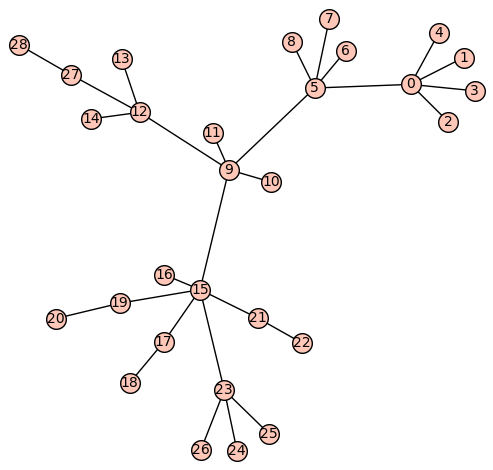

In [19]:
T.plot()

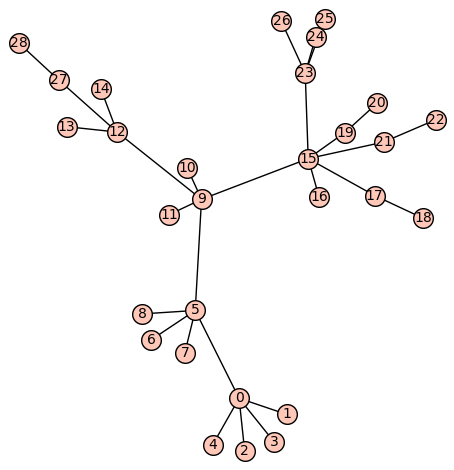

Leading partition: [5, 4, 4, 3, 3, 2, 2, 2, 2, 2]
1*st[29] - 9*st[28, 1] + 4*st[27, 2] + 36*st[27, 1, 1] - 32*st[26, 2, 1] - 84*st[26, 1, 1, 1] + 1*st[25, 4] + 6*st[25, 2, 2] + 112*st[25, 2, 1, 1] + 126*st[25, 1, 1, 1, 1] + 2*st[24, 5] - 9*st[24, 4, 1] + 1*st[24, 3, 2] - 42*st[24, 2, 2, 1] - 224*st[24, 2, 1, 1, 1] - 126*st[24, 1, 1, 1, 1, 1] - 15*st[23, 5, 1] + 4*st[23, 4, 2] + 35*st[23, 4, 1, 1] - 7*st[23, 3, 2, 1] + 4*st[23, 2, 2, 2] + 126*st[23, 2, 2, 1, 1] + 280*st[23, 2, 1, 1, 1, 1] + 84*st[23, 1, 1, 1, 1, 1, 1] + 7*st[22, 5, 2] + 49*st[22, 5, 1, 1] - 31*st[22, 4, 2, 1] - 77*st[22, 4, 1, 1, 1] + 3*st[22, 3, 2, 2] + 21*st[22, 3, 2, 1, 1] - 24*st[22, 2, 2, 2, 1] - 210*st[22, 2, 2, 1, 1, 1] - 224*st[22, 2, 1, 1, 1, 1, 1] - 36*st[22, 1, 1, 1, 1, 1, 1, 1] - 46*st[21, 5, 2, 1] - 91*st[21, 5, 1, 1, 1] + 6*st[21, 4, 2, 2] + 102*st[21, 4, 2, 1, 1] + 105*st[21, 4, 1, 1, 1, 1] - 18*st[21, 3, 2, 2, 1] - 35*st[21, 3, 2, 1, 1, 1] + 1*st[21, 2, 2, 2, 2] + 60*st[21, 2, 2, 2, 1, 1] + 210*st[21, 2,

array([ 1, -9,  4, ...,  0,  0,  0], shape=(4565,))

In [20]:
CSF_tree(T,1)